# Compute RMSE/STD and plot



Author: Dr Aminath Shausan
 

#### **Load libraries**

In [ ]:
# path = '<PUT PATH TO FOLDER'
import warnings
warnings.filterwarnings("ignore")

In [8]:
#import libraries
from datetime import datetime
import pandas as pd
import numpy as np

In [9]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors     

# from IPython.display import set_matplotlib_formats
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina', 'pdf')

matplotlib_inline.backend_inline.set_matplotlib_formats('png')
# plt.rcParams['savefig.dpi'] = 75
plt.rcParams['figure.autolayout'] = False
plt.rcParams['figure.figsize'] = (21, 30)  # A4
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['lines.markersize'] = 8
#plt.rcParams['text.usetex'] = True
plt.rcParams['text.usetex'] = False
plt.rcParams['font.size'] = 16
plt.rcParams['legend.fontsize'] = 16
#plt.rcParams['font.family'] = "serif"
plt.rcParams['font.family'] = "sans"
matplotlib.rcParams['xtick.major.pad']=12
matplotlib.rcParams['ytick.major.pad']=12

## Compute RMSE/STD
- Root mean squared error (RMSE) and scaled RMSE (RMSE/STD) where STD = standard deviation of the observed rates for the out-of-sample period

In [10]:

##################################################
#----------- name of the files (need to change w9 as per window size)
### w9_m0_noClimate
## w9_m1_tas_tasLag1
## w9_m1.2_tasIntRH
# w10_m2_tas_tasLag1_nonlinr 
## w9_m2.1_tasIntRH_nonlinr 

end_train_indexes = { # "w1": 12,  # "w2": 24,  
    "w3": 36,    "w4": 48,    "w5": 60,    "w6": 72,    "w7": 84,    "w8": 96,    "w9": 108,
    "w10": 119
}

## choose type of sensitivity (if computing forecast skill for sensitivity)
sens_type = 'main' ## 'main', sensitivity_imputed ## sensitivity_covid ## 'sensitivity_seasonality' 
# print(sens_type)
window = "w5"
print(window)
fileName = f"{window}_m2_tas_tasLag1_nonlinr" ## change this as per model
print(fileName)
end_train_indx = end_train_indexes[window]
print(end_train_indx)

 
n_origins = 25 if sens_type in [
    'main',
    'sensitivity_seasonality',
    'sensitivity_imputed'] else 13
print(n_origins)

colname_rmse = 'M3' ## change as per model
# col_names_rmse = {'sensitivity_imputed': 'M3_imp', 'sensitivity_seasonality': 'M3_season','sensitivity_covid': 'M3_pre_COVID'}
# colname_rmse = col_names_rmse[sens_type]
# colname_rmse = 'M3_log'
print(colname_rmse)

colname_std = 'STD'
# col_names_std = {'sensitivity_imputed': 'STD_imp', 'sensitivity_seasonality': 'STD_season','sensitivity_covid': 'STD_pre_COVID'}
# colname_std = col_names_std[sens_type]
# colname_std = 'STD_log'
print(colname_std)

senst_type_short = {'main': 'obs', 'sensitivity_imputed': 'imputed', 'sensitivity_seasonality': 'seasonality','sensitivity_covid': 'covid'}
df_save_name= senst_type_short[sens_type]
print(df_save_name)

w5
w5_m2_tas_tasLag1_nonlinr
60
25
M3
STD
obs


In [ ]:
##### read the fitted data
df_perf = pd.read_csv(path + 'results/model_fits/' + fileName + '.csv') ### use this for main analysis
# df_perf = pd.read_csv(path + 'results/model_fits/' + sens_type + '/' + fileName + '.csv') ## uncomment for sensitivity 

# print(df_perf.columns) 
print(df_perf.shape) ## 
df_perf = df_perf[(df_perf['ID.time' ] > end_train_indx)] #
print(df_perf.shape) 
df_perf 

###### Compute (observed - predicted)
df_perf2 = df_perf.copy()
df_perf2 = df_perf2[['state', 'date', 'year', 'month', 'obs', 'ID.time']]
df_perf2


for i in list(range(1,n_origins+1)): ## 
            colname = 'o'+ str(i)
            df_perf2[colname] = (df_perf['obs'] - df_perf[colname])
            # df_perf2[colname] = (np.log(df_perf['obs']+1) - np.log(df_perf[colname]+1)) ### use this for log scale RMSE computation

df_perf2

# #############  create each month ahead dfs 

lst_RMSE = [] 

for h_step in list(range(1,13)): 
    df = pd.DataFrame( {'state': ['NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']*h_step})
    
    ### prepare each month forecast df for each states 
    for i in list(range(1,n_origins+1)): ##
            colname = 'o'+ str(i) 
            w = h_step-1
            j = end_train_indx +i +w 
            df[colname] = df_perf2[df_perf2['ID.time'].isin(list(range(j-w,j+1)))][colname].values
            df3 = df.tail(7)        
            

    RMSE = df3.drop(columns=df.columns[0]) ## drop 1st col
    RMSE = RMSE ** 2 ## take sqr of each value
    RMSE = RMSE.mean(axis=0)  ## take mean across cols (fo each window, take mean across all states)
    RMSE = RMSE.mean() ## compute mean of all times
    RMSE = RMSE ** (1/2)
    lst_RMSE.append(RMSE.round(4))

print(len(lst_RMSE))

#######  create a df to hold RMSE 
df_rmse = pd.DataFrame({colname_rmse: lst_RMSE})
print(df_rmse.columns.tolist())
df_rmse


#### Compute STD of observed counts

In [ ]:
### get std of rate
lst_STD = []

for h_step in list(range(1,13)): ## 

    df_obs = pd.DataFrame( {'state': ['NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']*h_step})

    for i in list(range(1,n_origins+1)):  
        colname = 'obs'+ str(i)
        w = h_step-1

        j = end_train_indx +i +w
        df_obs[colname] = df_perf[df_perf['ID.time'].isin(list(range(j-w,j+1)))][['obs']].values ## 
        # df_obs[colname] = np.log(df_perf[df_perf['ID.time'].isin(list(range(j-w,j+1)))][['obs']].values +1) ## use this for the log scale sTD
        df_obs2 = df_obs.tail(7)


# # use sqrt(E[X^2] - (E[X])^(2))
    STD = df_obs2.drop(columns=df_obs.columns[0]) ##
    STD = STD **2
    STD = STD.mean(axis = 0).mean()
    STD = STD - (df_obs2.drop(columns=df_obs.columns[0]).mean(axis=0).mean()) ** 2
    STD = STD ** (1/2)
     
    
    lst_STD.append(STD)

print(len(lst_STD))


df_obs2.head()


##########
df_rmse[colname_std] = lst_STD
df_rmse

#####
## save df_rmse
df_rmse.to_csv(path + 'results/model_fits/df_rmse_obs_' + window + '.csv', index = False)
# df_rmse

In [ ]:
########### (DO THIS ONLY for SENSITIVITY analysis) #####################
## read previously computed df_rmse for 
# df_rmse_senstvty = pd.read_csv(path + 'results/model_fitsdf_rmse_obs_'+ window+ '.csv')

# print(df_rmse_senstvty.dtypes)
# df_rmse_senstvty

## df_rmse_senstvty['M3_log'] = df_rmse['M3_log']
## df_rmse_senstvty['STD_log'] = df_rmse['STD_log']


# df_rmse_senstvty[colname_rmse] = df_rmse[colname_rmse]
# df_rmse_senstvty[colname_std] = df_rmse[colname_std]

## save df_rmse
# df_rmse_senstvty.to_csv(path + 'results/' + sens_type + '/df_rmse_' + df_save_name +'_' + window+ '.csv', index = False)
## df_rmse_senstvty.to_csv(path + 'results/model_fit/df_rmse_logscale_' + window + '.csv', index = False)

# df_rmse_senstvty


In [ ]:
del fig

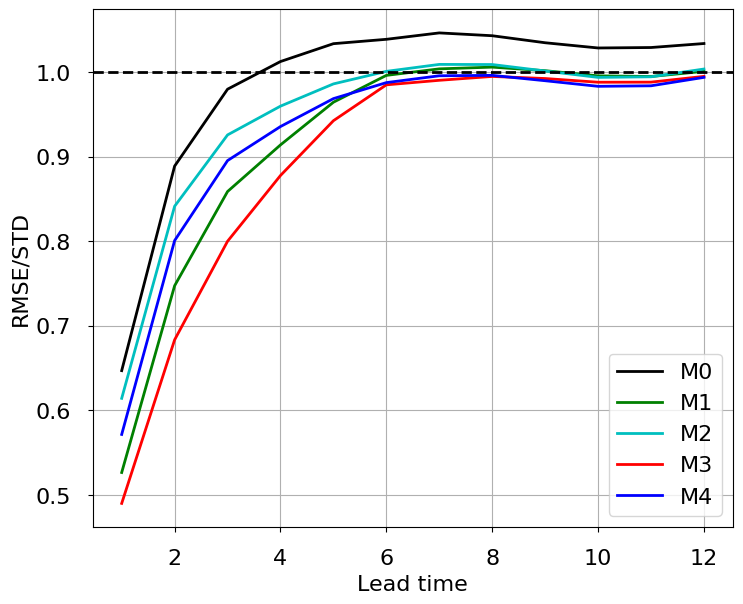

In [ ]:

# ### plot rmse/std
### read saved df_rmse for each window 

df_rmse = pd.read_csv(path + 'results/model_fits/df_rmse_obs_' + window + '.csv')
# df_rmse = pd.read_csv(path + 'results/' + sens_type + '/df_rmse_' + df_save_name +window + '.csv') ## uncomment for sensitivity plots

leadTime = range(1,13)
lst_models = ['M0', 'M1', 'M2','M3', 'M4',] 
# lst_models = ['M3', colname_rmse]  ## uncomment for sensitivity
 

colours = dict()

colours['M0'] = 'k' 
colours['M1'] = 'g'
colours['M2'] = 'c'
colours['M3'] = 'r'
colours['M4'] = 'b'

# colours[colname_rmse] = 'm'

fig=plt.figure()
ax = plt.subplot(5,3,1)
plt.ylabel('RMSE/STD')
 
for model in lst_models: #df_rmse['model'].unique():
    plt.plot(leadTime, df_rmse[model]/df_rmse['STD'], '-', color=colours[model], label=str(model)) ## 'model:'
    # plt.plot(leadTime, df_rmse[colname_rmse]/df_rmse[colname_std], '-', color= 'm', label= colname_rmse) ##use this for sensitivity plots

plt.axhline(y=1.0, color='k', linestyle='--')
plt.grid(); plt.xlabel('Lead time'); plt.legend(loc='lower right')

plt.tight_layout()

## save
plt.savefig(path + '/figs/'+ window + '_model_comparision.pdf', dpi=300,bbox_inches='tight')
# plt.savefig(path + '/figs/'+ window + '_M3_' + df_save_name + '.pdf', dpi=300,bbox_inches='tight')




## Compute RMSE/STD dataframes for the primary analysis

In [ ]:
window = 'w3'
df_rmse = pd.read_csv(path + 'results/model_fits/df_rmse_obs_' +window + '.csv')
df_rmse

df_perform = pd.DataFrame()
lst_models = ['M0', 'M1', 'M2','M3', 'M4']  
for model in lst_models: 
    df_perform[model] = round(df_rmse[model]/df_rmse['STD'],5)

df_perform